<a href="https://colab.research.google.com/github/Bharat-KR25/Numpy-and-pandas-projects/blob/main/assn2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(6433, 14)
pickup             datetime64[ns]
dropoff            datetime64[ns]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                      object
payment                    object
pickup_zone                object
dropoff_zone               object
pickup_borough             object
dropoff_borough            object
dtype: object 

Missing values per column:
 payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64
Remaining missing values: 0
Final shape: (6407, 14)


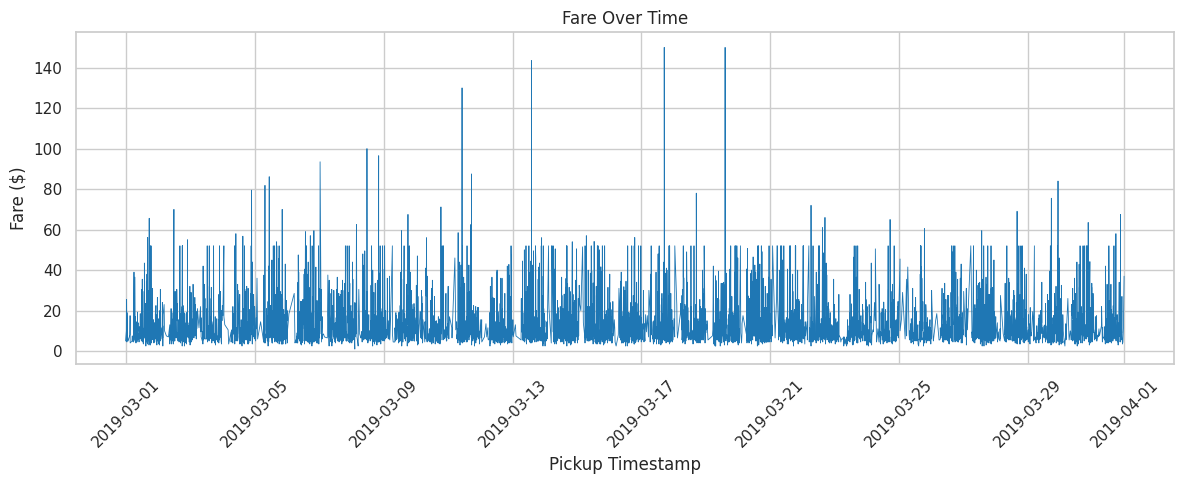

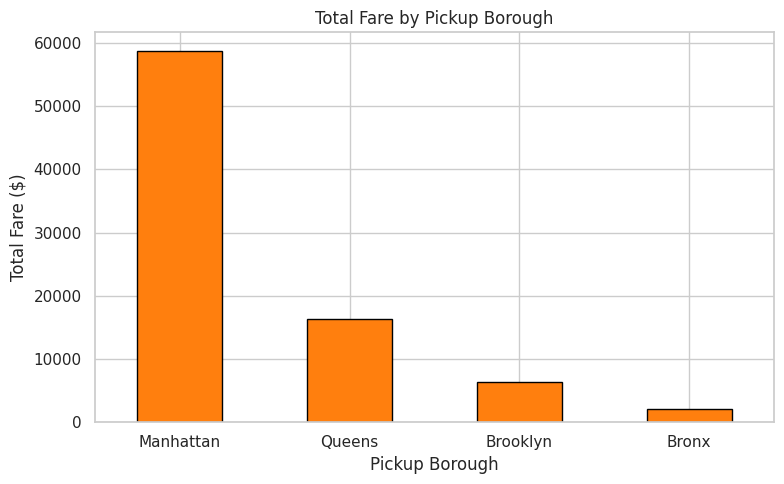

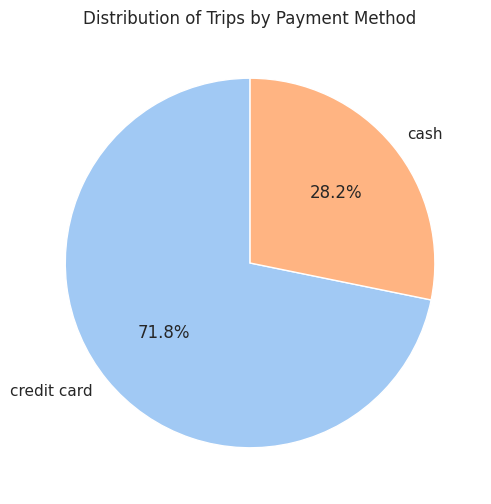

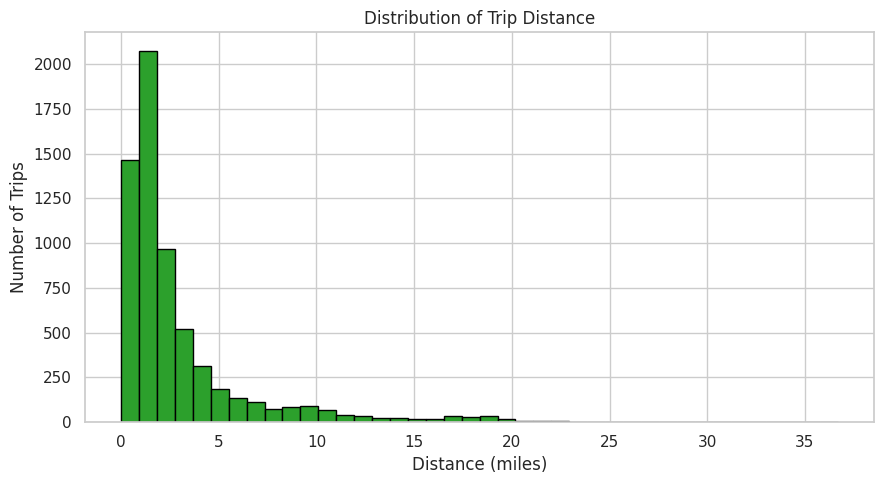

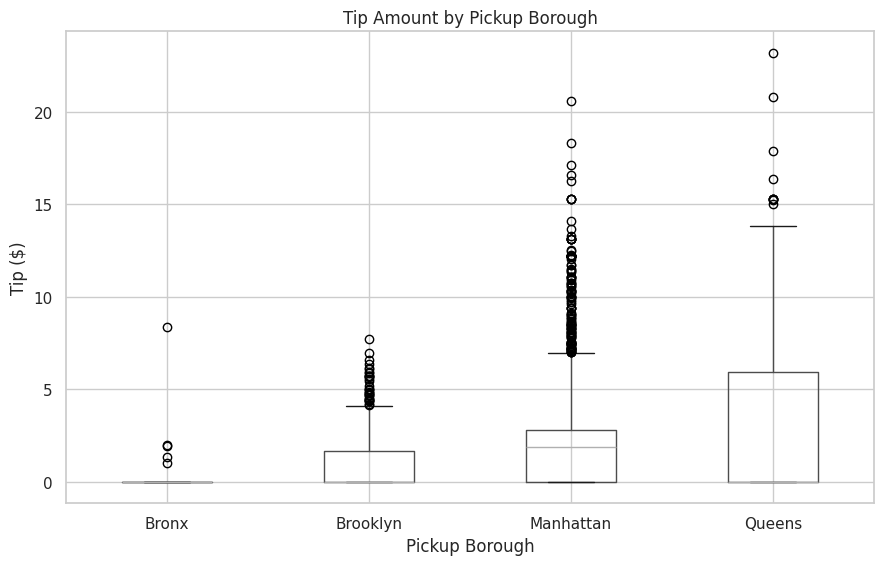

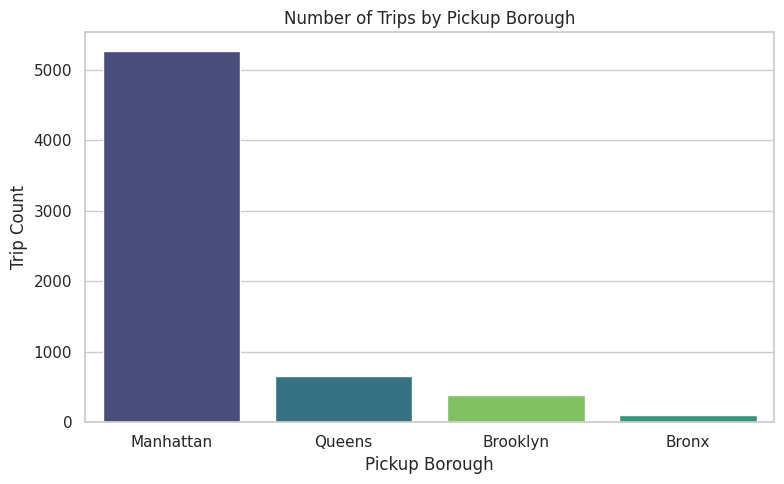

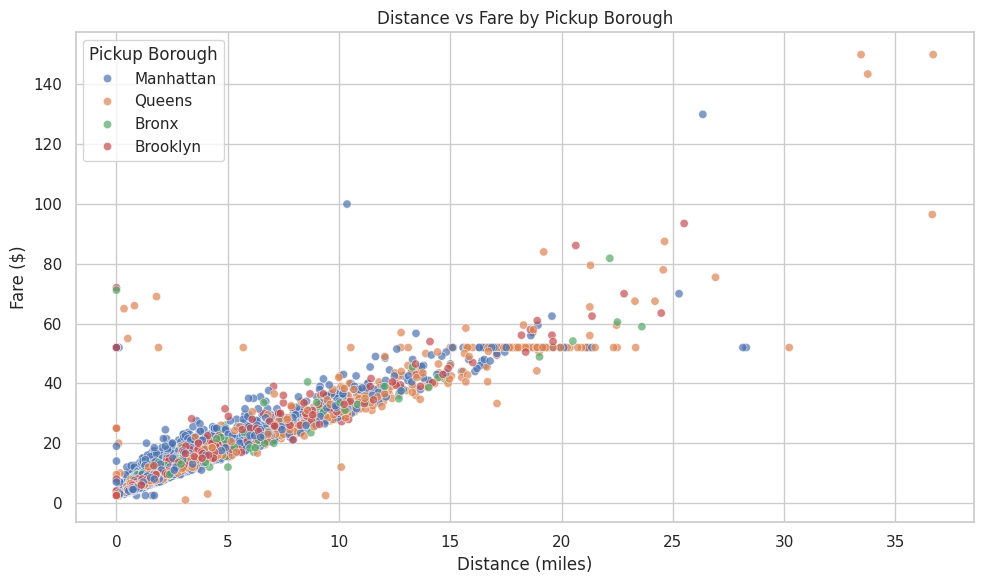

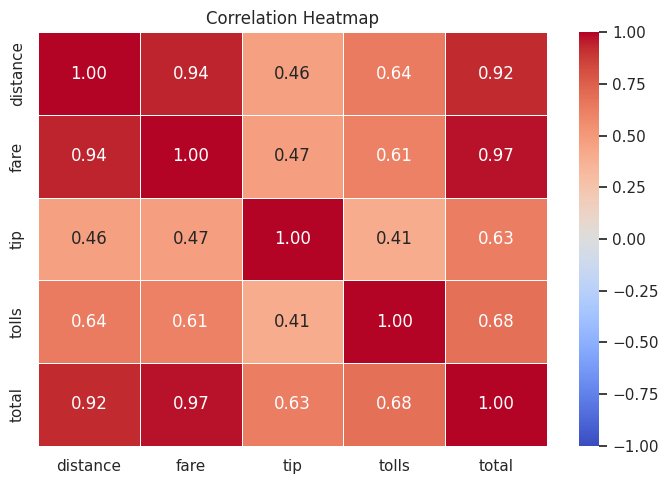

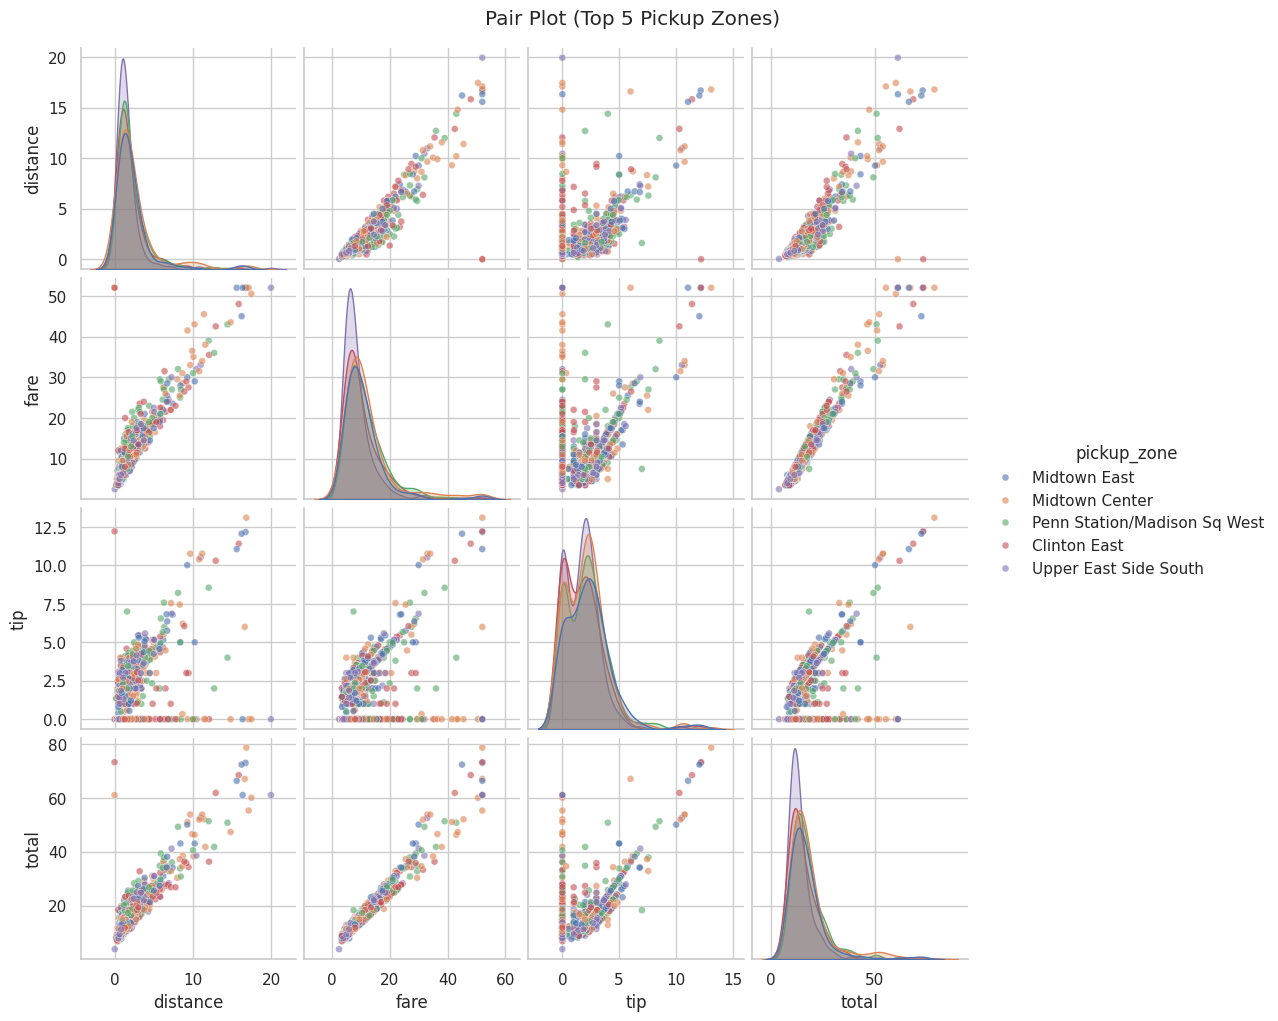

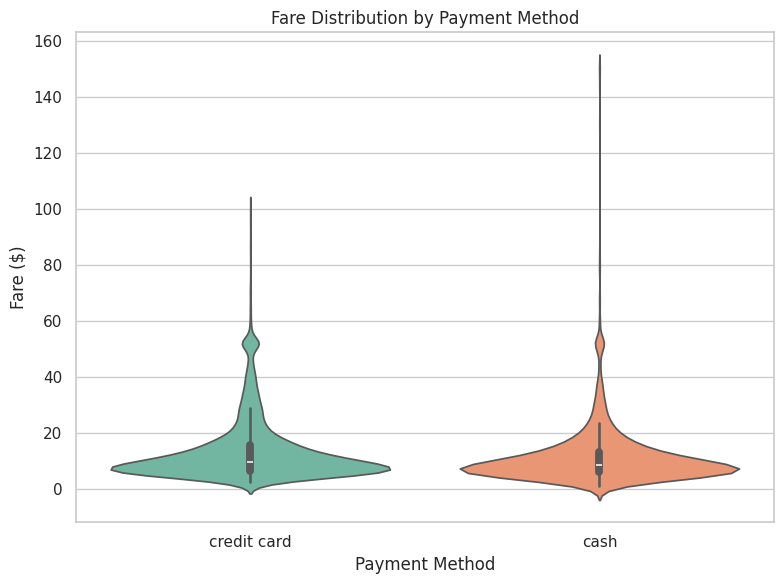

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ---------------- 1) Load dataset ----------------
df = sns.load_dataset("taxis")
print(df.shape)
df.head()

# ---------------- 2) Handling missing values ----------------
print(df.dtypes, "\n")
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])

# Numerical columns: impute with median (none are missing here, kept for completeness)
for col in df.select_dtypes(include="number").columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Categorical, non-critical columns: impute with mode
df["payment"] = df["payment"].fillna(df["payment"].mode()[0])
for col in ["dropoff_zone", "dropoff_borough"]:
    df[col] = df[col].fillna(df[col].mode()[0])

# Critical columns (pickup location): drop rows, no reasonable imputation
df = df.dropna(subset=["pickup_borough", "pickup_zone"]).reset_index(drop=True)

# Convert timestamps to datetime
df["pickup"] = pd.to_datetime(df["pickup"])
df["dropoff"] = pd.to_datetime(df["dropoff"])

print("Remaining missing values:", df.isnull().sum().sum())
print("Final shape:", df.shape)

# ---------------- 3) Matplotlib / Pandas plots ----------------

# Line chart: fare over time
d = df.sort_values("pickup")
plt.figure(figsize=(12, 5))
plt.plot(d["pickup"], d["fare"], linewidth=0.6, color="tab:blue")
plt.title("Fare Over Time")
plt.xlabel("Pickup Timestamp")
plt.ylabel("Fare ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------- Bar chart: total fare per pickup borough ----------------
fare_by_borough = df.groupby("pickup_borough")["fare"].sum().sort_values(ascending=False)
ax = fare_by_borough.plot(kind="bar", figsize=(8, 5), color="tab:orange", edgecolor="black")
ax.set_title("Total Fare by Pickup Borough")
ax.set_xlabel("Pickup Borough")
ax.set_ylabel("Total Fare ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------- Pie chart: trips by payment method ----------------
pay = df["payment"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(pay, labels=pay.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("pastel"), wedgeprops={"edgecolor": "white"})
plt.title("Distribution of Trips by Payment Method")
plt.show()

# ---------------- Histogram: distance ----------------
plt.figure(figsize=(9, 5))
plt.hist(df["distance"], bins=40, color="tab:green", edgecolor="black")
plt.title("Distribution of Trip Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

# ---------------- Box plot: tip by pickup borough ----------------
df.boxplot(column="tip", by="pickup_borough", figsize=(9, 6), grid=True)
plt.suptitle("")
plt.title("Tip Amount by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip ($)")
plt.tight_layout()
plt.show()

# ---------------- 4) Seaborn plots ----------------

# Count plot
plt.figure(figsize=(8, 5))
order = df["pickup_borough"].value_counts().index
sns.countplot(data=df, x="pickup_borough", order=order,
              hue="pickup_borough", palette="viridis", legend=False)
plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Trip Count")
plt.tight_layout()
plt.show()

# ---------------- Scatter plot: distance vs fare ----------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="distance", y="fare", hue="pickup_borough", alpha=0.7)
plt.title("Distance vs Fare by Pickup Borough")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.legend(title="Pickup Borough")
plt.tight_layout()
plt.show()

# ---------------- Heatmap: correlation ----------------
corr = df[["distance", "fare", "tip", "tolls", "total"]].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ---------------- Pair plot (top 5 pickup zones for readability) ----------------
top_zones = df["pickup_zone"].value_counts().head(5).index
pp_df = df[df["pickup_zone"].isin(top_zones)]
g = sns.pairplot(pp_df, vars=["distance", "fare", "tip", "total"], hue="pickup_zone",
                 diag_kind="kde", plot_kws={"alpha": 0.6, "s": 25})
g.figure.suptitle("Pair Plot (Top 5 Pickup Zones)", y=1.02)
plt.show()

# ---------------- Violin plot: fare by payment method ----------------
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x="payment", y="fare", hue="payment", palette="Set2", legend=False)
plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare ($)")
plt.tight_layout()
plt.show()